In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import mne

/kaggle/input/openneuro-ds004504/ds004504/participants.tsv
/kaggle/input/openneuro-ds004504/ds004504/derivatives/sub-060/eeg/sub-060_task-eyesclosed_eeg.set
/kaggle/input/openneuro-ds004504/ds004504/derivatives/sub-003/eeg/sub-003_task-eyesclosed_eeg.set
/kaggle/input/openneuro-ds004504/ds004504/derivatives/sub-012/eeg/sub-012_task-eyesclosed_eeg.set
/kaggle/input/openneuro-ds004504/ds004504/derivatives/sub-057/eeg/sub-057_task-eyesclosed_eeg.set
/kaggle/input/openneuro-ds004504/ds004504/derivatives/sub-015/eeg/sub-015_task-eyesclosed_eeg.set
/kaggle/input/openneuro-ds004504/ds004504/derivatives/sub-048/eeg/sub-048_task-eyesclosed_eeg.set
/kaggle/input/openneuro-ds004504/ds004504/derivatives/sub-034/eeg/sub-034_task-eyesclosed_eeg.set
/kaggle/input/openneuro-ds004504/ds004504/derivatives/sub-010/eeg/sub-010_task-eyesclosed_eeg.set
/kaggle/input/openneuro-ds004504/ds004504/derivatives/sub-043/eeg/sub-043_task-eyesclosed_eeg.set
/kaggle/input/openneuro-ds004504/ds004504/derivatives/sub-0

In [ ]:
sns.set_style("whitegrid")

DATA_PATH = "/kaggle/input/openneuro-ds004504/ds004504"


In [3]:
def load_subject(subject_id: int, path: str = DATA_PATH) -> mne.io.Raw:
    """loads subject using their numeric id in the data folders"""
    return mne.io.read_raw_eeglab(path + '/derivatives/sub-' + str(subject_id).zfill(3)
                                  + '/eeg/sub-' + str(subject_id).zfill(3) + '_task-eyesclosed_eeg.set', preload=True, verbose='CRITICAL')

In [4]:
raw = load_subject(15)

In [5]:
print(raw.info)

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, ...
 chs: 19 EEG
 custom_ref_applied: False
 dig: 22 items (3 Cardinal, 19 EEG)
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 19
 projs: []
 sfreq: 500.0 Hz
>


Using matplotlib as 2D backend.


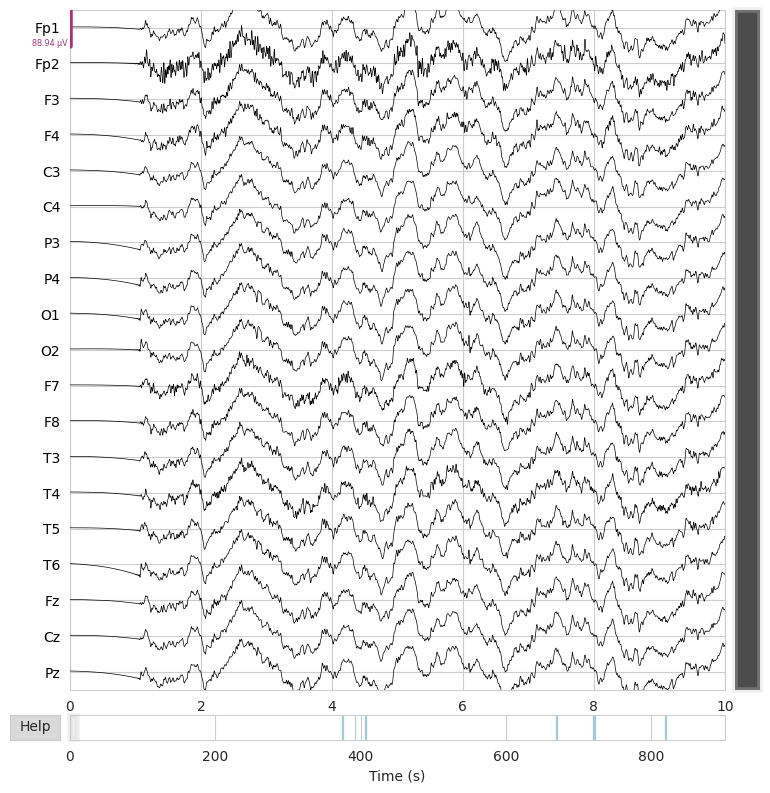

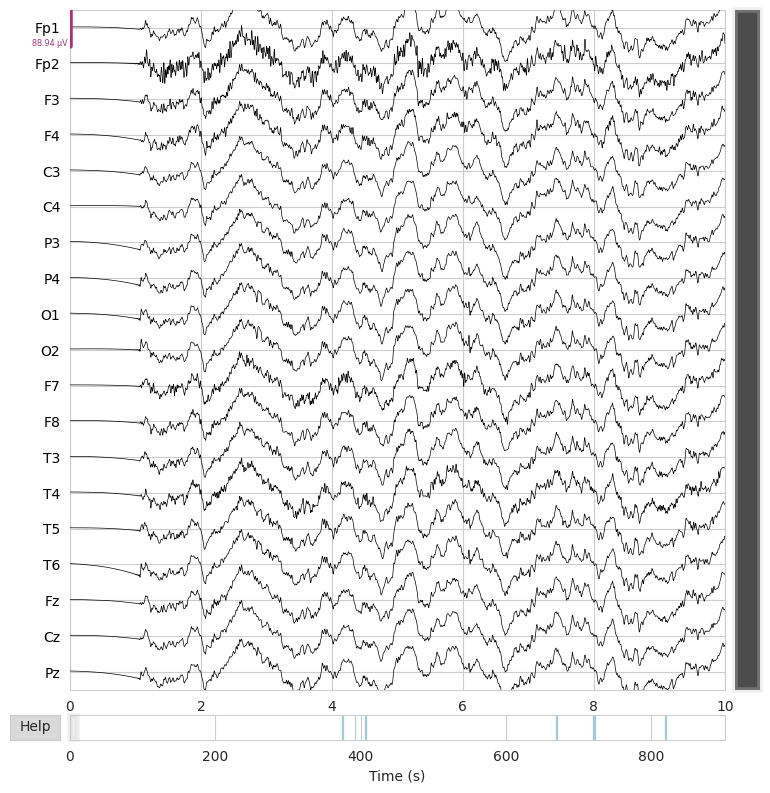

In [6]:
raw.plot(n_channels=19, scalings='auto', title='Raw EEG Data Example', show=True)

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


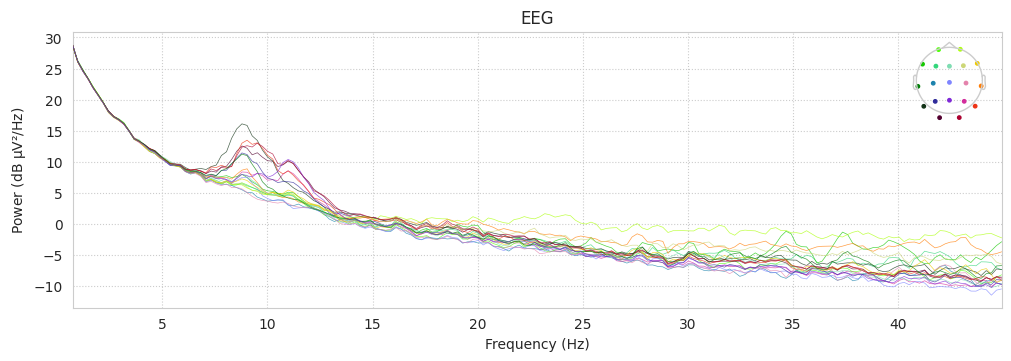

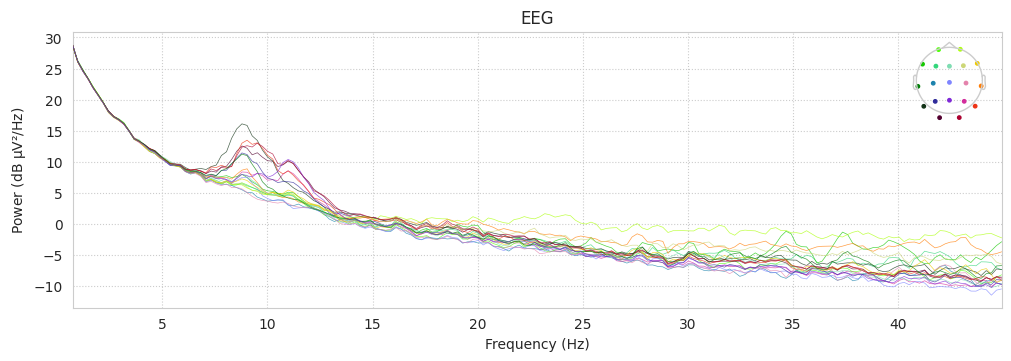

In [7]:
raw.plot_psd(fmin=0.5, fmax=45)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


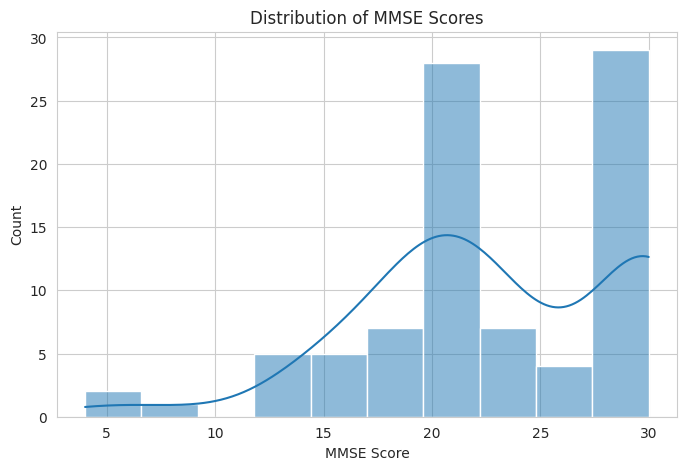

In [8]:
df_metadata = pd.read_csv("/kaggle/input/openneuro-ds004504/ds004504/participants.tsv", sep="\t")

plt.figure(figsize=(8, 5))
sns.histplot(df_metadata['MMSE'], bins=10, kde=True)
plt.xlabel("MMSE Score")
plt.ylabel("Count")
plt.title("Distribution of MMSE Scores")
plt.show()

Band power summary:
            Delta         Theta         Alpha          Beta
Fp1  6.932633e-10  3.665051e-11  1.491882e-11  9.087305e-12
Fp2  6.958416e-10  3.653399e-11  1.507289e-11  1.850893e-11
F3   6.938831e-10  3.738432e-11  1.506472e-11  1.067636e-11
F4   6.897658e-10  3.740298e-11  1.514554e-11  1.286081e-11
C3   6.888146e-10  3.587799e-11  1.268023e-11  8.581209e-12
C4   6.824428e-10  3.584998e-11  1.230350e-11  8.652317e-12
P3   6.928967e-10  3.901241e-11  3.150767e-11  1.033272e-11
P4   6.918750e-10  3.785293e-11  2.579144e-11  9.793237e-12
O1   6.936990e-10  4.137690e-11  4.885995e-11  1.216476e-11
O2   6.945553e-10  4.192815e-11  5.443420e-11  1.270764e-11
F7   7.144638e-10  3.872009e-11  1.772202e-11  1.127827e-11
F8   6.759529e-10  3.618676e-11  1.667166e-11  9.955200e-12
T3   6.891907e-10  3.944533e-11  2.551458e-11  1.009805e-11
T4   6.814719e-10  3.839758e-11  1.843113e-11  1.407593e-11
T5   6.922713e-10  4.464059e-11  6.697617e-11  1.235205e-11
T6   6.987802e-10  4

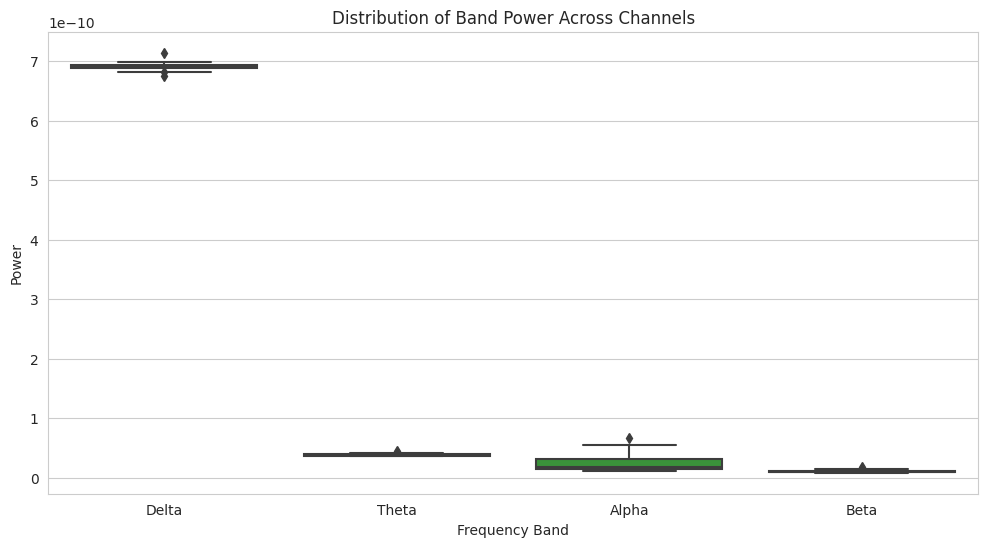

In [9]:
data, times = raw[:]
eeg_df = pd.DataFrame(data.T, columns=raw.ch_names)
eeg_df['Time'] = times

# Compute band power for different frequency bands
def bandpower(data, sf, band, window_sec=4):
    from scipy.signal import welch
    band = np.array(band)
    low, high = band
    nperseg = int(window_sec * sf)
    freqs, psd = welch(data, sf, nperseg=nperseg)
    idx_band = np.logical_and(freqs >= low, freqs <= high)
    return np.trapz(psd[idx_band], freqs[idx_band])

sf = raw.info['sfreq']
bands = {'Delta': (0.5, 4), 'Theta': (4, 8), 'Alpha': (8, 13), 'Beta': (13, 30)}
band_powers = {band: [] for band in bands}

for ch in raw.ch_names:
    signal = eeg_df[ch].values
    for band, freq_range in bands.items():
        band_powers[band].append(bandpower(signal, sf, freq_range))

band_powers_df = pd.DataFrame(band_powers, index=raw.ch_names)
print("Band power summary:")
print(band_powers_df)

# Visualize band power distribution
plt.figure(figsize=(12, 6))
sns.boxplot(data=band_powers_df)
plt.xlabel("Frequency Band")
plt.ylabel("Power")
plt.title("Distribution of Band Power Across Channels")
plt.show()

# Psd comparision between 3 classes

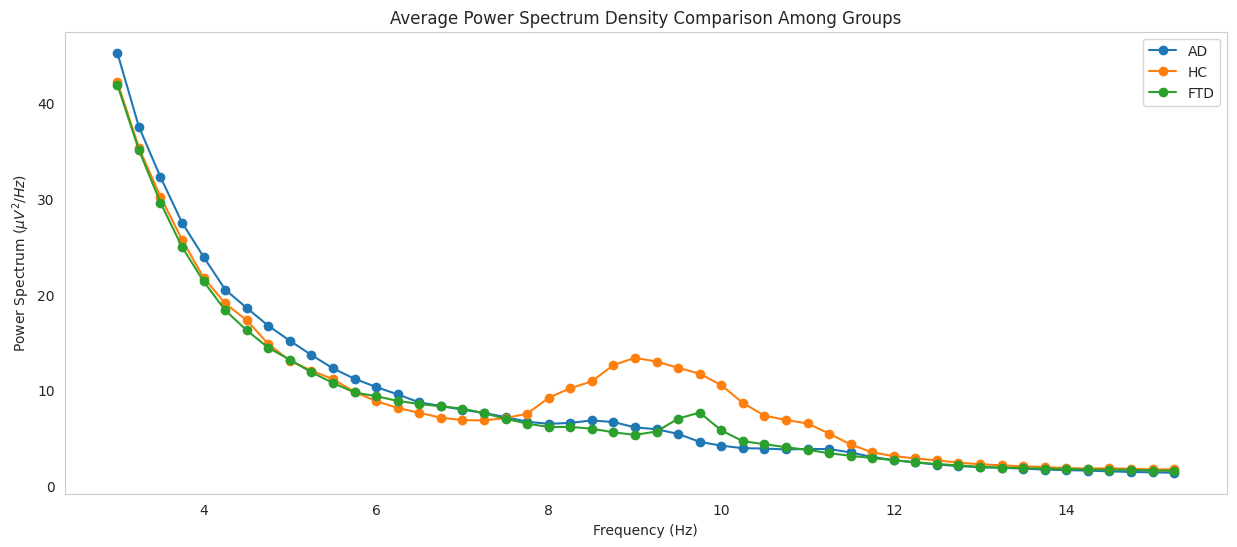

In [10]:
group_ranges = {
    'AD': range(1, 37),      # subjects 1-36 for AD
    'HC': range(37, 66),    # subjects 37-65 for HC
    'FTD': range(66, 89)      # subjects 66-89 for FTD
}

group_psd = {}  

for group, subject_ids in group_ranges.items():
    spectrum_array_all = []
    for i in subject_ids:
        raw = load_subject(i)  
        spectrum = raw.compute_psd(method='welch', 
                                   fmin=0.5, 
                                   fmax=45, 
                                   n_fft=int(4*raw.info['sfreq']), 
                                   verbose=False)
        spectrum_array, freqs = spectrum.get_data(return_freqs=True)
        spectrum_array = (10**12) * spectrum_array  
        spectrum_array_all.append(spectrum_array)
    avg_psd = np.mean(np.array(spectrum_array_all), axis=0)
    group_psd[group] = avg_psd

# Plot
plt.figure(figsize=(15, 6))
for group, avg_psd in group_psd.items():
    mean_psd = np.mean(avg_psd, axis=0)
    plt.plot(freqs[10:60], mean_psd[10:60], '-o', label=group)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectrum ($\\mu V^2 / Hz$)')
plt.title("Average Power Spectrum Density Comparison Among Groups")
plt.grid()
plt.legend()
plt.show()

# Psd comparision between channels

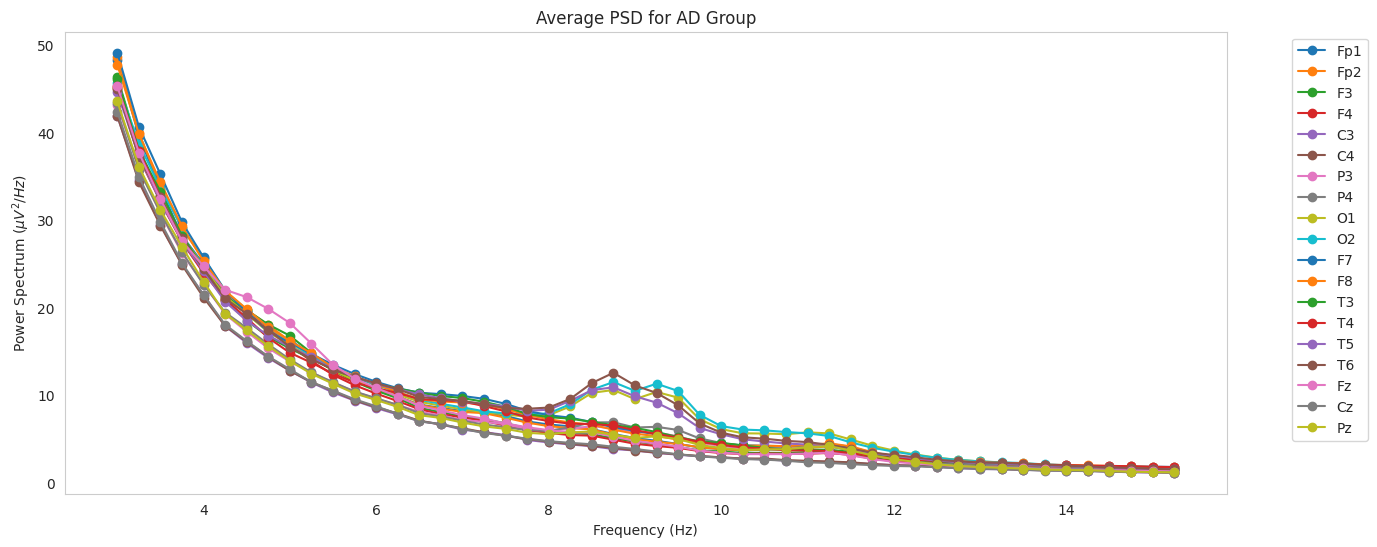

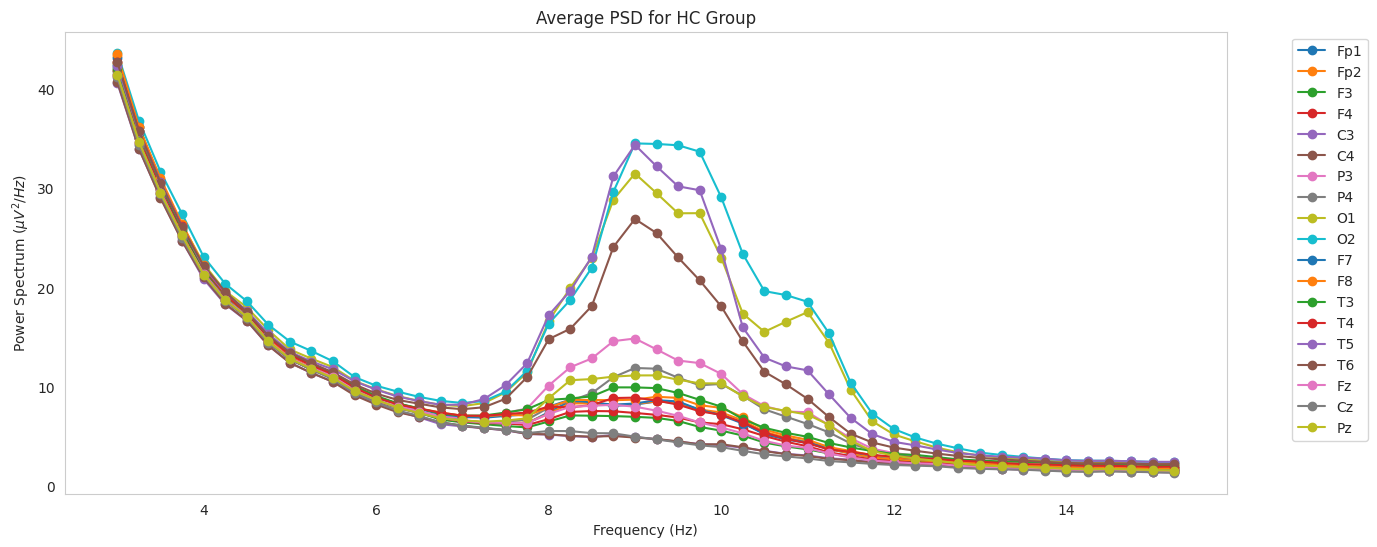

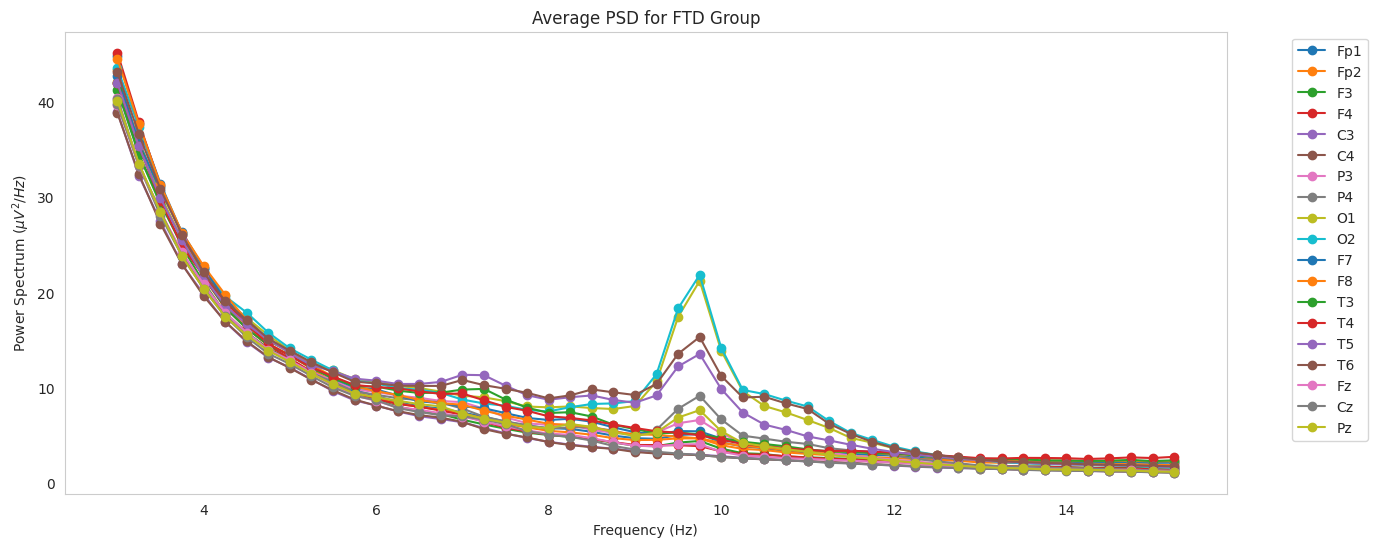

In [11]:
for group, avg_psd in group_psd.items():
    plt.figure(figsize=(15, 6))
    # avg_psd shape: (n_channels, n_freqs)
    for ch_idx in range(avg_psd.shape[0]):
        plt.plot(freqs[10:60], avg_psd[ch_idx, 10:60], '-o', label=raw.info.ch_names[ch_idx])
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power Spectrum ($\\mu V^2 / Hz$)')
    plt.title(f"Average PSD for {group} Group")
    plt.grid()
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

# Topomap comparision each group

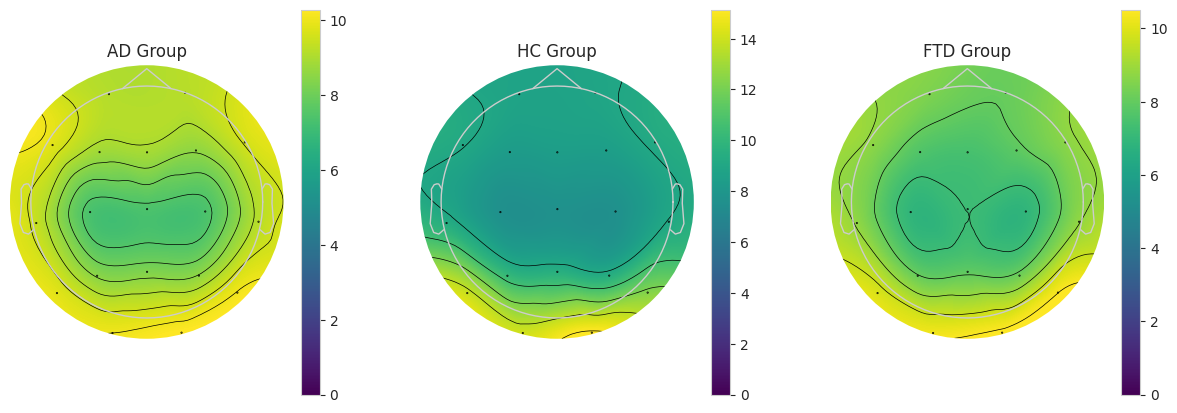

In [12]:
group_topomap = {}
for group, avg_psd in group_psd.items():
    topo = np.mean(avg_psd[:, 10:60], axis=1) 
    group_topomap[group] = topo

fig, axes = plt.subplots(1, len(group_topomap), figsize=(15, 5))
for ax, (group, topo) in zip(axes, group_topomap.items()):
    im, cbar = mne.viz.plot_topomap(topo, raw.info, axes=ax, cmap='viridis', show=False)
    ax.set_title(f"{group} Group")
    fig.colorbar(im, ax=ax)
plt.show()

# Conclusion

#### Further analysis may involve feature extraction, classification, and connectivity analysis.  
